## All the imports
import data set and all libraries that will be used later


In [106]:
import pandas as pd

from matplotlib import pyplot as plt 
%matplotlib inline

import numpy as np
import seaborn as sb #heatmap

from sklearn.preprocessing import StandardScaler

# models
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# nn
import tensorflow as tf

# evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# path to the file to read
pcos_file_path = 'data\data without infertility _final.csv'

pcos_data = pd.read_csv(pcos_file_path) 

## Data info
seeing some statistics about the data

In [72]:
print("Columns BEFORE stripping:")
print(list(pcos_data.columns))

pcos_data.columns = pcos_data.columns.str.strip()

print("\nColumns AFTER stripping:")
print(list(pcos_data.columns))


Columns BEFORE stripping:
['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 42']

Columns AFTER stripping:
['Sl. No', 'Patient File No.', 'PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marrai

<Axes: >

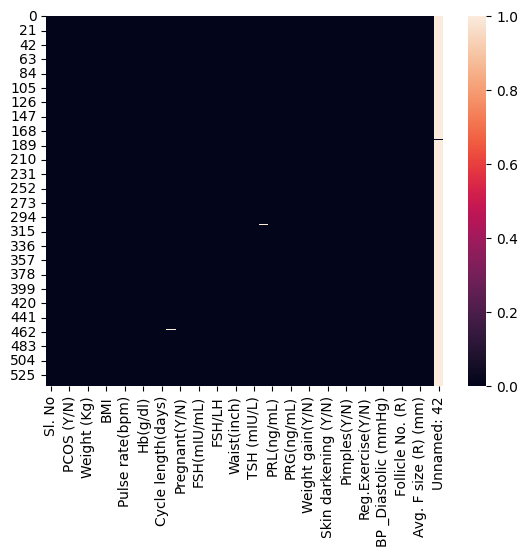

In [73]:
#to see empty data ; in our case it is col 42
sb.heatmap(pcos_data.isnull())

## Cleaning data
We have to remove null values and all values should be numerical

In [74]:
#dropping col that has all null values, and then id cols cause they are not needed for the clasification
#axis=1 is for col axis=0 is for rows
pcos_data.drop(["Unnamed: 42", "Sl. No", "Patient File No."], axis=1, inplace=True)

<Axes: >

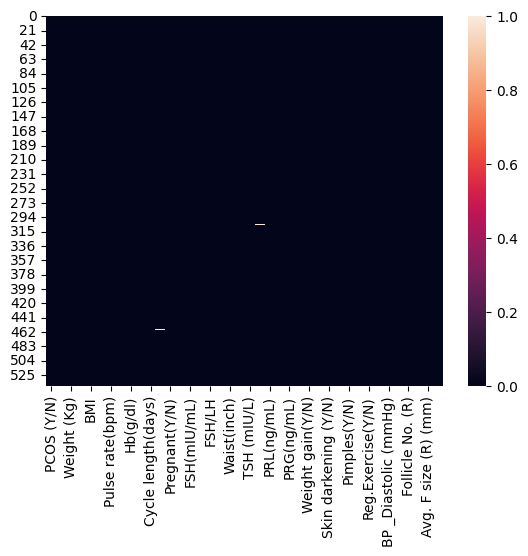

In [75]:
sb.heatmap(pcos_data.isnull())

In [76]:
pcos_data.isnull().sum()

PCOS (Y/N)               0
Age (yrs)                0
Weight (Kg)              0
Height(Cm)               0
BMI                      0
Blood Group              0
Pulse rate(bpm)          0
RR (breaths/min)         0
Hb(g/dl)                 0
Cycle(R/I)               0
Cycle length(days)       0
Marraige Status (Yrs)    1
Pregnant(Y/N)            0
No. of aborptions        0
FSH(mIU/mL)              0
LH(mIU/mL)               0
FSH/LH                   0
Hip(inch)                0
Waist(inch)              0
Waist:Hip Ratio          0
TSH (mIU/L)              0
AMH(ng/mL)               1
PRL(ng/mL)               0
Vit D3 (ng/mL)           0
PRG(ng/mL)               0
RBS(mg/dl)               0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
Hair loss(Y/N)           0
Pimples(Y/N)             0
Fast food (Y/N)          1
Reg.Exercise(Y/N)        0
BP _Systolic (mmHg)      0
BP _Diastolic (mmHg)     0
Follicle No. (L)         0
Follicle No. (R)         0
A

In [77]:
pcos_data["Cycle(R/I)"] = pcos_data["Cycle(R/I)"].map({
    2: 0,  # Regular
    4: 1   # Irregular
})
# Channging the value of Irregular/regular cycles

### Setting features

In [78]:
hormone_features = [
    "FSH(mIU/mL)",
    "LH(mIU/mL)",
    "FSH/LH",
    "AMH(ng/mL)",
    "TSH (mIU/L)",
    "PRL(ng/mL)",
    "PRG(ng/mL)"  
]

patient_observable_features = [
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "Pregnant(Y/N)",
    "No. of aborptions",
    "Cycle(R/I)",             # Regular/Irregular periods
    "Cycle length(days)",     # length of period
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"       # lifestyle activity
]

doctor_observable_features = [
    # Patient-reported symptoms
    "Cycle(R/I)",
    "Cycle length(days)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)",
    
    # Doctor-observed measurements
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "BMI",
    "Pulse rate(bpm)",
    "RR (breaths/min)",
    "Hb(g/dl)",
    "Hip(inch)",
    "Waist(inch)",
    "Waist:Hip Ratio",
    "BP _Systolic (mmHg)",
    "BP _Diastolic (mmHg)",
    
    # Ultrasound / gynecologist measurements
    "Follicle No. (L)",
    "Follicle No. (R)",
    "Avg. F size (L) (mm)",
    "Avg. F size (R) (mm)",
    "Endometrium (mm)"
]


In [79]:
# all features except ids and target
# all_features = pcos_data.drop(columns=['PCOS (Y/N)'], axis=1)

all_features = list(pcos_data.drop(columns=['PCOS (Y/N)']).columns)

print(all_features)


['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']


Assigning what features we wanna use

In [80]:
pcos_features = doctor_observable_features

Last cleaning data procces is removing null values from feature list

In [81]:
# dropna drops missing values (think of na as "not available")
pcos_data = pcos_data.dropna(
    subset=pcos_features + ["PCOS (Y/N)"]
)
#drop a row only if one of features or pcos label is missing

In [82]:
pcos_data[pcos_features].isnull().sum()


Cycle(R/I)              0
Cycle length(days)      0
Weight gain(Y/N)        0
hair growth(Y/N)        0
Skin darkening (Y/N)    0
Hair loss(Y/N)          0
Pimples(Y/N)            0
Fast food (Y/N)         0
Reg.Exercise(Y/N)       0
Age (yrs)               0
Weight (Kg)             0
Height(Cm)              0
BMI                     0
Pulse rate(bpm)         0
RR (breaths/min)        0
Hb(g/dl)                0
Hip(inch)               0
Waist(inch)             0
Waist:Hip Ratio         0
BP _Systolic (mmHg)     0
BP _Diastolic (mmHg)    0
Follicle No. (L)        0
Follicle No. (R)        0
Avg. F size (L) (mm)    0
Avg. F size (R) (mm)    0
Endometrium (mm)        0
dtype: int64

## Separating predictor and targets

In [83]:
# By convention, this data (features) is called X.
X = pcos_data[pcos_features]

# want to predict if paitent has pcos or no
y = pcos_data["PCOS (Y/N)"]

In [84]:
X.head()

,Cycle(R/I),Cycle length(days),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),Age (yrs),...,Hip(inch),Waist(inch),Waist:Hip Ratio,BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0.0,5,0,0,0,0,0,1.0,0,28,...,36,30,0.833333,110,80,3,3,18.0,18.0,8.5
1,0.0,5,0,0,0,0,0,0.0,0,36,...,38,32,0.842105,120,70,3,5,15.0,14.0,3.7
2,0.0,5,0,0,0,1,1,1.0,0,33,...,40,36,0.900000,120,80,13,15,18.0,20.0,10.0
3,0.0,5,0,0,0,0,0,0.0,0,37,...,42,36,0.857143,120,70,2,2,15.0,14.0,7.5
4,0.0,5,0,0,0,1,0,0.0,0,25,...,37,30,0.810811,120,80,3,4,16.0,14.0,7.0


In [85]:
y.value_counts()

PCOS (Y/N)
0    363
1    176
Name: count, dtype: int64

<Axes: ylabel='count'>

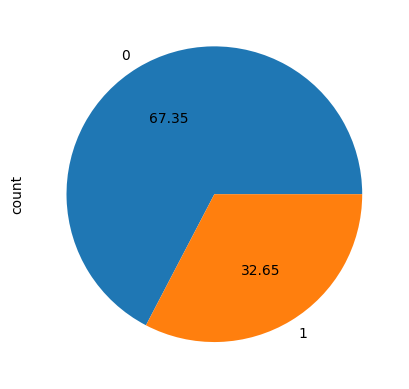

In [86]:
y.value_counts().plot.pie(autopct='%.2f')

## Spliting data into train and test

In [87]:
#the function train_test_split returns 4 diff values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=67)
# if you ever want to repeat the same split, you have to repeat random_state num
# apperently Keras does val split for monitoring
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=67)



## Scale the data - normalize 

In [88]:
#create a scaler object so that we can normalize the data
scaler = StandardScaler()

# fit the scaler to the data and then transform the data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_val = scaler.transform(X_val)


# Logistic Regression

## Train the model

In [ ]:
logistic_model = LogisticRegression(
    max_iter=500,
    random_state=67
)
# missing pcos patients is worse than misclassifying a non PCOS-patient
# so the clas 1 weights twice more than class 0

# https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/
param_grid_LR = {
    "C": [0.1, 1, 2],
    "class_weight": [
        None,
        {0:1, 1:1.5},
        {0:1, 1:2},
    ]
}

grid_search_LR = GridSearchCV(estimator=logistic_model, param_grid=param_grid_LR, cv=10, scoring="recall", n_jobs=-1,verbose=2)

grid_search_LR.fit(X_train, y_train)

best_lr = grid_search_LR.best_estimator_

print("Best params:", grid_search_LR.best_params_)
print("Best CV recall:", grid_search_LR.best_score_)



Fitting 10 folds for each of 12 candidates, totalling 120 fits
Best params: {'C': 0.1, 'class_weight': {0: 1, 1: 2}}
Best CV recall: 0.7945454545454546


## Evaluation

In [90]:
y_probs = best_lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_probs>= 0.4).astype(int)

accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Test Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Test Accuracy: 0.8519

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.80      0.88        89
           1       0.71      0.96      0.81        46

    accuracy                           0.85       135
   macro avg       0.84      0.88      0.85       135
weighted avg       0.88      0.85      0.86       135


Confusion Matrix:
 [[71 18]
 [ 2 44]]


# Random Forest Classifier

## Train the model


In [91]:
rf_model = RandomForestClassifier(random_state=67)

# https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/
param_grid_RF = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [None, 5, 10, 15],       
    'max_features':["sqrt", "log2"],    
    'min_samples_leaf': [1, 2, 4],  
     "class_weight": [
        None,
        {0:1, 1:1.5},
        {0:1, 1:2},
    ]              
}
#dictionary with parameters names (str) as keys and lists of parameter settings


#scoring strategy to evaluate the performance of the cross-validated model on the test set. I choose recall because i want least number of false negatives
#n_jobs -> -1 means using all processors
#verbose : Controls the verbosity: the higher, the more messages. ( опширност )
grid_search = GridSearchCV(rf_model, param_grid_RF, cv=10, scoring='recall', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best parameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Fitting 10 folds for each of 216 candidates, totalling 2160 fits
Best parameters:  {'class_weight': {0: 1, 1: 2}, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
Best score:  0.7909090909090908


## Evaluation

In [92]:
y_predictions_rf = best_rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_predictions_rf)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_predictions_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predictions_rf))

Test Accuracy: 0.9185

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94        89
           1       0.83      0.96      0.89        46

    accuracy                           0.92       135
   macro avg       0.90      0.93      0.91       135
weighted avg       0.93      0.92      0.92       135


Confusion Matrix:
 [[80  9]
 [ 2 44]]


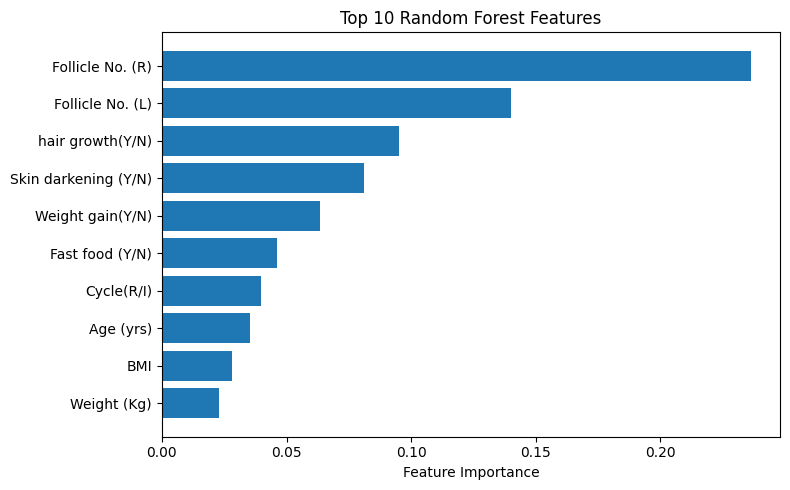

In [93]:
feature_importances = best_rf.feature_importances_
feature_names = doctor_observable_features
sorted_indices = np.argsort(feature_importances)[::-1]

top_k = 10
indices = sorted_indices[:top_k]

plt.figure(figsize=(8,5))
plt.barh(
    np.array(feature_names)[indices][::-1],
    feature_importances[indices][::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 10 Random Forest Features")
plt.tight_layout()
plt.show()


# Artificial Neural Network

In [ ]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy(history):
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_recall(history):
    plt.plot(history.history['recall'], label='train_recall')
    plt.plot(history.history['val_recall'], label='val_recall')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def create_model(neurons=8, activation='relu',optimizer='adam'):
    model = Sequential()
    model.add(Dense(neurons, input_dim=X_scaled.shape[1], activation=activation))
    model.add(Dense(1, activation='sigmoid'))  # binary classification
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy', 'recall'])
    return model

model = KerasClassifier(build_fn=create_model, verbose=0)

param_grid = {
    'neurons': [4, 8, 12],           # "fn <= 3" style: small hidden layer sizes
    'activation': ['relu', 'tanh'],
    'optimizer': ['adam', 'rmsprop'],
    'batch_size': [10, 20],
    'epochs': [50, 100]
}

grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='recall', n_jobs=-1)

print(f"Best Accuracy: {grid_result.best_score_:.4f}")
print(f"Best Parameters: {grid_result.best_params_}")


c:\Users\PC-2\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721 (2.82 KB)

 Trainable params: 721 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

nn_model.compile(                       # default learning rate for Adam
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='binary_crossentropy', 
    metrics=['accuracy',tf.keras.metrics.Recall(name='recall')]
)


nn_model.summary()

In [102]:
history = nn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=0
)

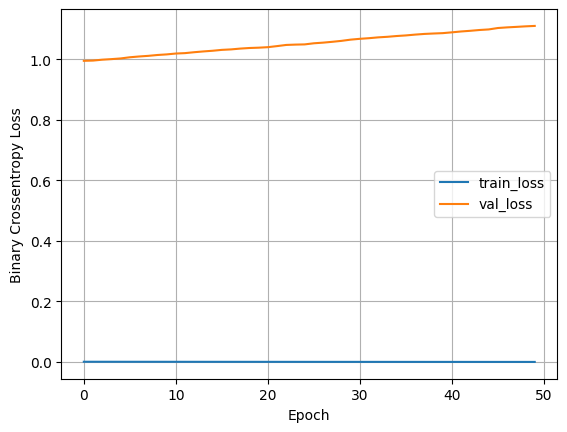

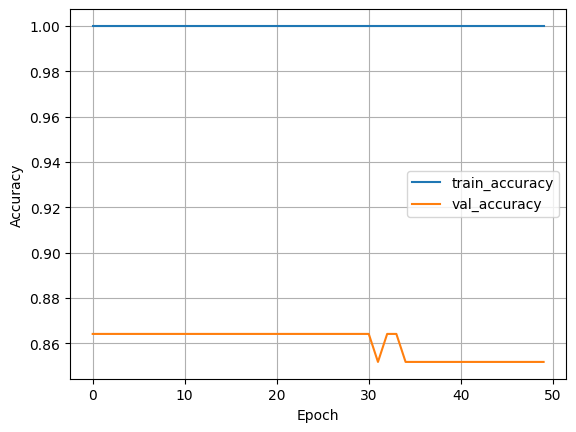

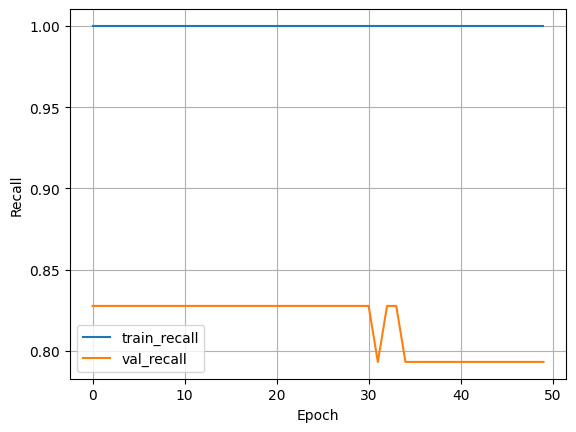

In [103]:
plot_loss(history)
plot_accuracy(history)
plot_recall(history)